<a href="https://colab.research.google.com/github/gagan3754/Jamboree-Education---Linear-Regression/blob/main/Jamboree_Education_Linear_Regression_polished_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Jamboree has helped thousands of students like you make it to top colleges abroad. Be it GMAT, GRE or SAT, their unique problem-solving methods ensure maximum scores with minimum effort.
They recently launched a feature where students/learners can come to their website and check their probability of getting into the IVY league college. This feature estimates the chances of graduate admission from an Indian perspective.


How can you help here?

Your analysis will help Jamboree in understanding what factors are important in graduate admissions and how these factors are interrelated among themselves. It will also help predict one's chances of admission given the rest of the variables.


Dataset:

Dataset Link: jamboree_admission.csv


Column Profiling:

Serial No. (Unique row ID)

GRE Scores (out of 340)

TOEFL Scores (out of 120)

University Rating (out of 5)

Statement of Purpose and Letter of Recommendation Strength (out of 5)

Undergraduate GPA (out of 10)

Research Experience (either 0 or 1)

Chance of Admit (ranging from 0 to 1)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('/content/Jamboree_Admission.csv')

In [ ]:
df.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


The datatypes of the columns

In [ ]:
# data types of column in data frame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No.         500 non-null    int64  
 1   GRE Score          500 non-null    int64  
 2   TOEFL Score        500 non-null    int64  
 3   University Rating  500 non-null    int64  
 4   SOP                500 non-null    float64
 5   LOR                500 non-null    float64
 6   CGPA               500 non-null    float64
 7   Research           500 non-null    int64  
 8   Chance of Admit    500 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 35.3 KB


shape of Dataset

In [ ]:
print('No of Columns : ',df.shape[1])
print('No of Rows : ',df.shape[0])

No of Columns :  9
No of Rows :  500


In [ ]:
df.shape

(500, 9)

There are 9 columns and 500 rows in Dataframe

There are spaces in name of columns let's strip it now

In [ ]:
df.columns=df.columns.str.strip()

Let us drop the Unique identifier Serial No. from the data frame as it does not add any meaning during linear regression

In [ ]:
#droping unique identifier
df.drop(columns=['Serial No.'],inplace=True)

In [ ]:
df.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65


The no of unique values for all columns

In [ ]:
#printing unique values
for col in df.columns:
  print("No of unique values of ",col,": ",df[col].nunique())
  print("-"*50)

No of unique values of  GRE Score :  49
--------------------------------------------------
No of unique values of  TOEFL Score :  29
--------------------------------------------------
No of unique values of  University Rating :  5
--------------------------------------------------
No of unique values of  SOP :  9
--------------------------------------------------
No of unique values of  LOR :  9
--------------------------------------------------
No of unique values of  CGPA :  184
--------------------------------------------------
No of unique values of  Research :  2
--------------------------------------------------
No of unique values of  Chance of Admit :  61
--------------------------------------------------


summary of DataFrame

In [ ]:
#printing the summary
print('Summary : ')
df.describe()

Summary : 


,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
count,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.00000
mean,316.472000,107.192000,3.114000,3.374000,3.48400,8.576440,0.560000,0.72174
std,11.295148,6.081868,1.143512,0.991004,0.92545,0.604813,0.496884,0.14114
min,290.000000,92.000000,1.000000,1.000000,1.00000,6.800000,0.000000,0.34000
25%,308.000000,103.000000,2.000000,2.500000,3.00000,8.127500,0.000000,0.63000
50%,317.000000,107.000000,3.000000,3.500000,3.50000,8.560000,1.000000,0.72000
75%,325.000000,112.000000,4.000000,4.000000,4.00000,9.040000,1.000000,0.82000
max,340.000000,120.000000,5.000000,5.000000,5.00000,9.920000,1.000000,0.97000


The value of counts for each category in a column

In [ ]:
#printing the vale count of each column
for col in df.columns[:-1]:
  print(df[col].value_counts())
  print("-"*50)

GRE Score
312    24
324    23
316    18
322    17
327    17
321    17
311    16
320    16
314    16
325    15
317    15
308    13
323    13
315    13
300    12
319    12
313    12
326    12
304    12
318    12
305    11
310    11
301    11
307    10
329    10
299    10
298    10
331     9
328     9
309     9
340     9
330     8
334     8
332     8
302     7
306     7
297     6
296     5
303     5
336     5
295     5
333     4
338     4
335     4
339     3
337     2
294     2
290     2
293     1
Name: count, dtype: int64
--------------------------------------------------
TOEFL Score
110    44
105    37
104    29
106    28
107    28
112    28
103    25
100    24
102    24
99     23
111    20
101    20
108    19
109    19
113    19
114    18
116    16
115    11
118    10
119    10
98     10
120     9
117     8
97      7
96      6
95      3
93      2
94      2
92      1
Name: count, dtype: int64
--------------------------------------------------
University Rating
3    162
2    126
4    105

Find the missing value in dataframe

In [ ]:
print("Missing Values : ")
df.isnull().sum()

Missing Values : 


,0
GRE Score,0
TOEFL Score,0
University Rating,0
SOP,0
LOR,0
CGPA,0
Research,0
Chance of Admit,0


There are no missing values in the data frame

Visualization to get data distribution

In [ ]:
df1=df.copy()

In [ ]:
df1.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65


For visualization in the project converting University Rating , SOP ,LOR, Research to Category for visualization since it is ordinal data

In [ ]:
#converting from int to category
df1['University Rating']=df1['University Rating'].astype('category')
df1['SOP']=df1['SOP'].astype('category')
df1['LOR']=df1['LOR'].astype('category')
df1['Research']=df1['Research'].astype('category')

In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   GRE Score          500 non-null    int64   
 1   TOEFL Score        500 non-null    int64   
 2   University Rating  500 non-null    category
 3   SOP                500 non-null    category
 4   LOR                500 non-null    category
 5   CGPA               500 non-null    float64 
 6   Research           500 non-null    category
 7   Chance of Admit    500 non-null    float64 
dtypes: category(4), float64(2), int64(2)
memory usage: 18.8 KB


In [ ]:
cat_columns=df1.select_dtypes('category').columns
num_columns=df1.select_dtypes(['int','float']).columns

Univariate Analysis

Categorical variable plotting countplot

In [ ]:
plt.rcParams['figure.figsize']=(16,10)

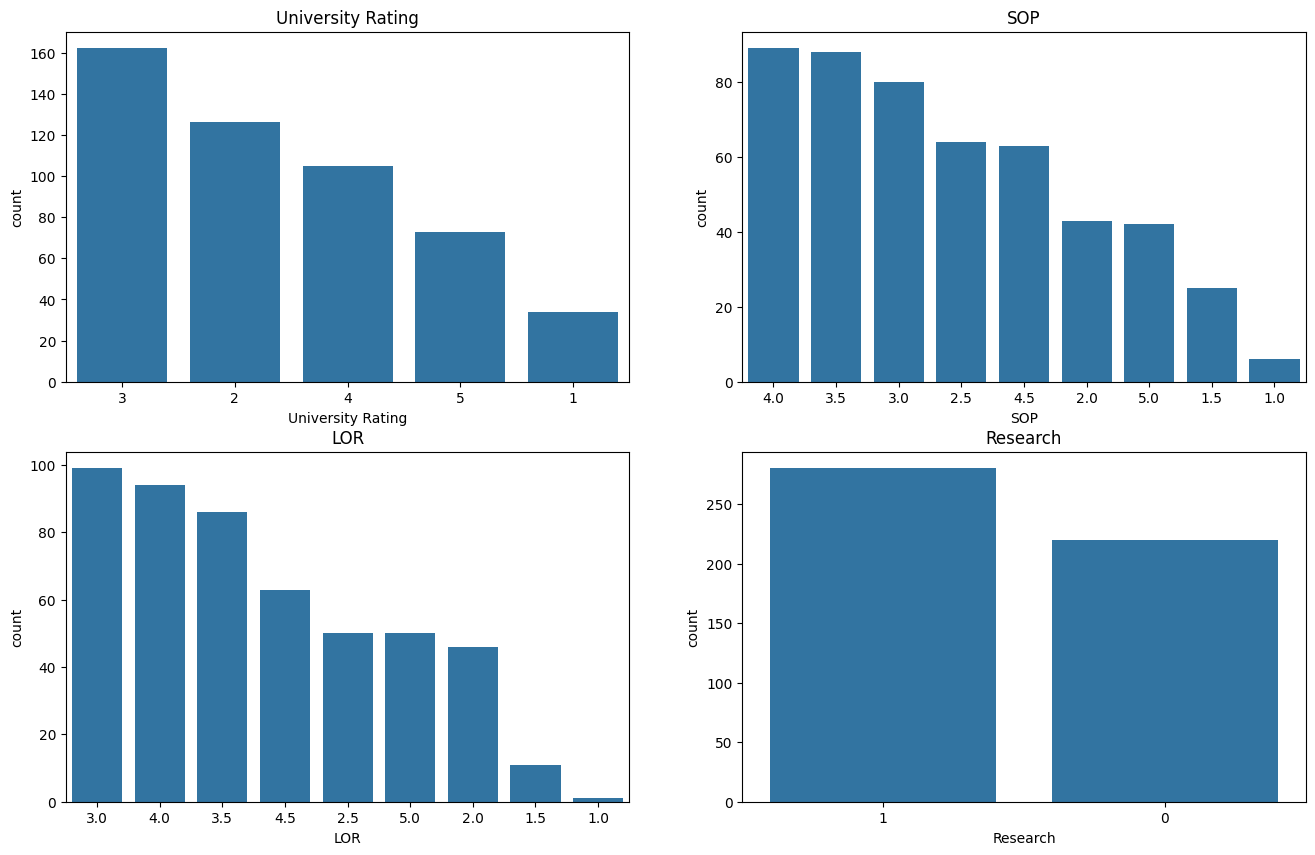

In [ ]:
#Categorical variable
i=1
for col in cat_columns:
  plt.subplot(2,2,i)
  sns.countplot(x=df1[col],order=df1[col].value_counts().index)
  plt.title(f'{col}')
  plt.xlabel(f'{col}')
  i+=1
plt.show()

From the above plot we can conclude that

University Rating - 3 has highest count followed by 2,4,5,1

SOP(Statement of Purpose) - 4.0 has highest count

LOR(Letter of Recommendation) - 3.0 has highest count

Research - 1 has highest count

Now distribution plot for numerical value

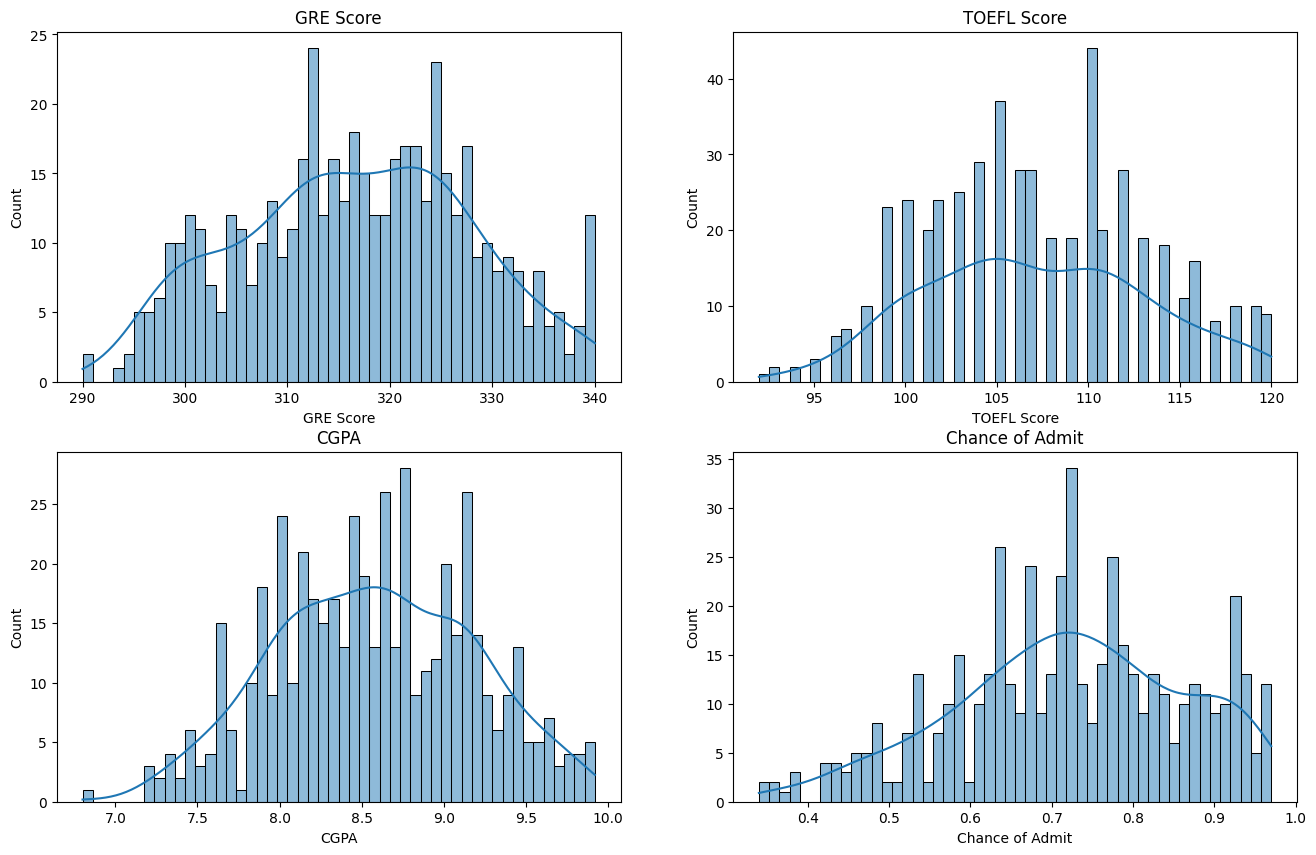

In [ ]:
#Numerical values
i=1
for col in num_columns:
  plt.subplot(2,2,i)
  sns.histplot(x=df1[col],bins=50,kde=True)
  plt.title(f"{col}")
  plt.xlabel(f"{col}")
  i+=1
plt.show()

Distribution of GRE score is Normal distribution but not perfectly Gaussian

Distribution of TOEFL score is Normal(Gaussian) distribution but slightly left skewed

Distribution of CGPA is Guassian Distribution perfectly

Distribution of Chance of Admit is Normal distribution with left skewed

To find outliers we have to plot boxplot for numerical variable

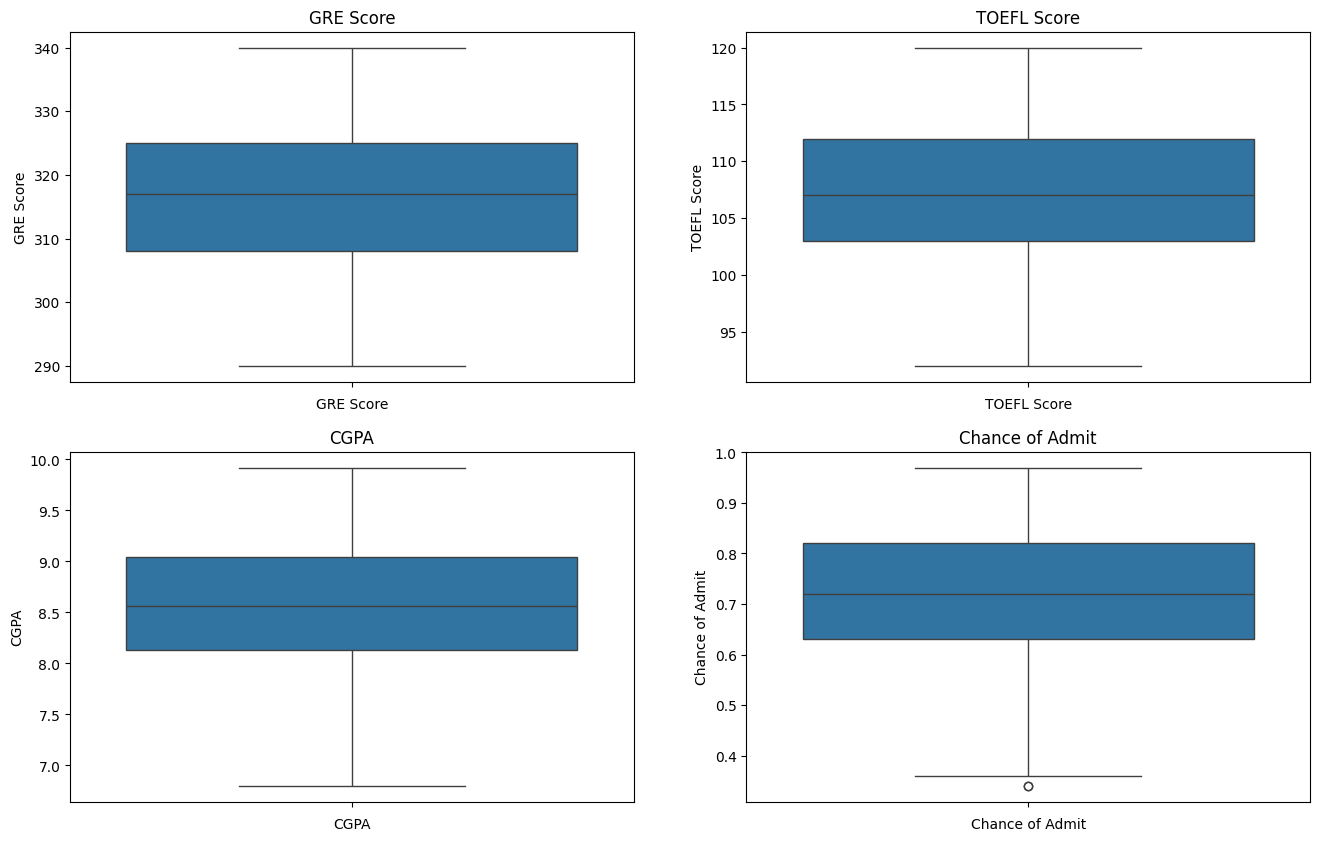

In [ ]:
i=1
for col in num_columns:
  plt.subplot(2,2,i)
  sns.boxplot(df1[col])
  plt.title(f"{col}")
  plt.xlabel(f"{col}")
  i+=1
plt.show()

By above Boxplots we can conclude that there are no outliers

Bivariate Analysis Visualization

Barplots for categorical variable and numerical target variable (chance of admit)

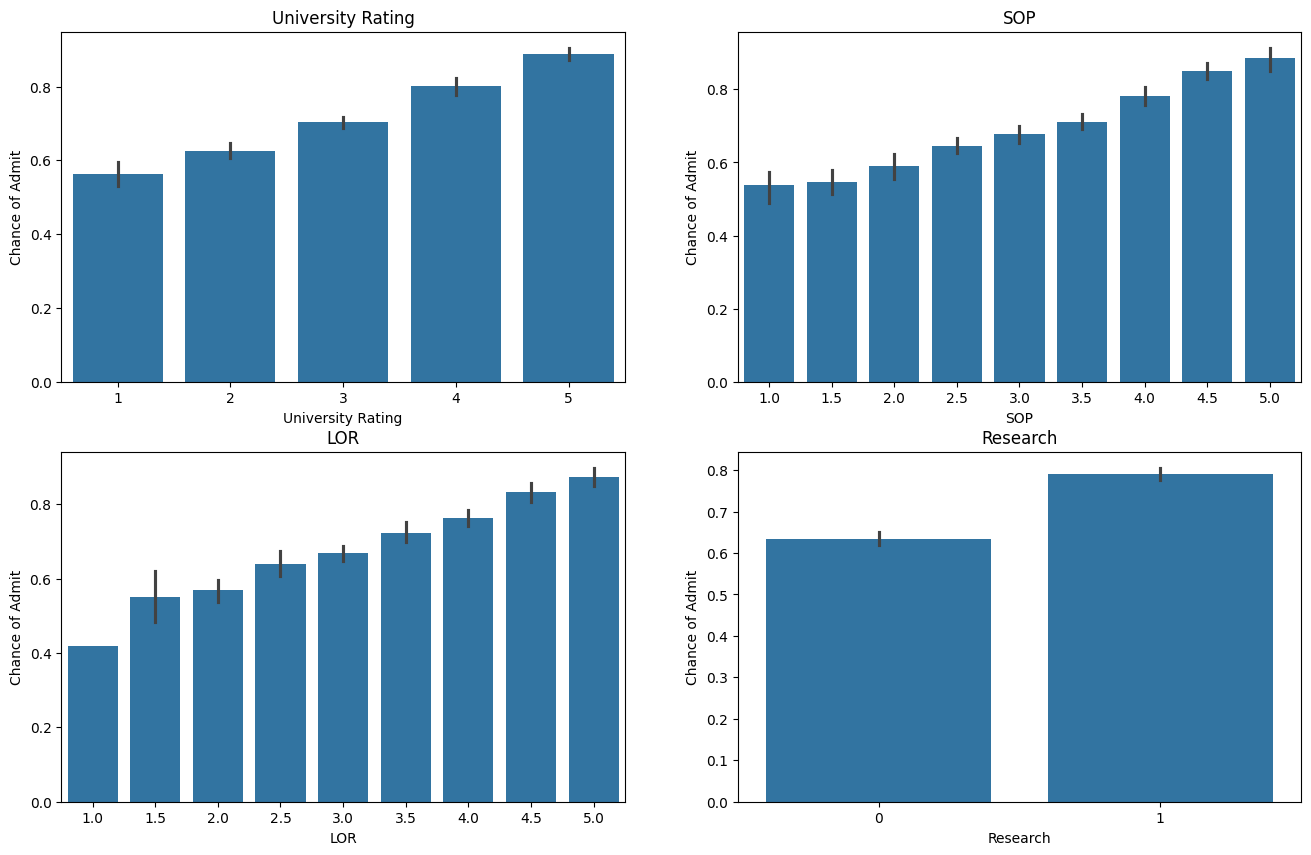

In [ ]:
target=df1['Chance of Admit']
i=1
for col in cat_columns:
  plt.subplot(2,2,i)
  sns.barplot(x=df1[col],y=target,estimator='mean')
  plt.title(f"{col}")
  plt.xlabel(f"{col}")
  i+=1
plt.show()

According to the Visulaization

University Rating with 5 has higher chance of University

SOP with 5 has higher chance of admit to University

LOR with 5.0 has higher chance of admit to University

Research with 1 has higher chance of admit to University

Plot boxplot for numerical target vs categorical variable to find outliers

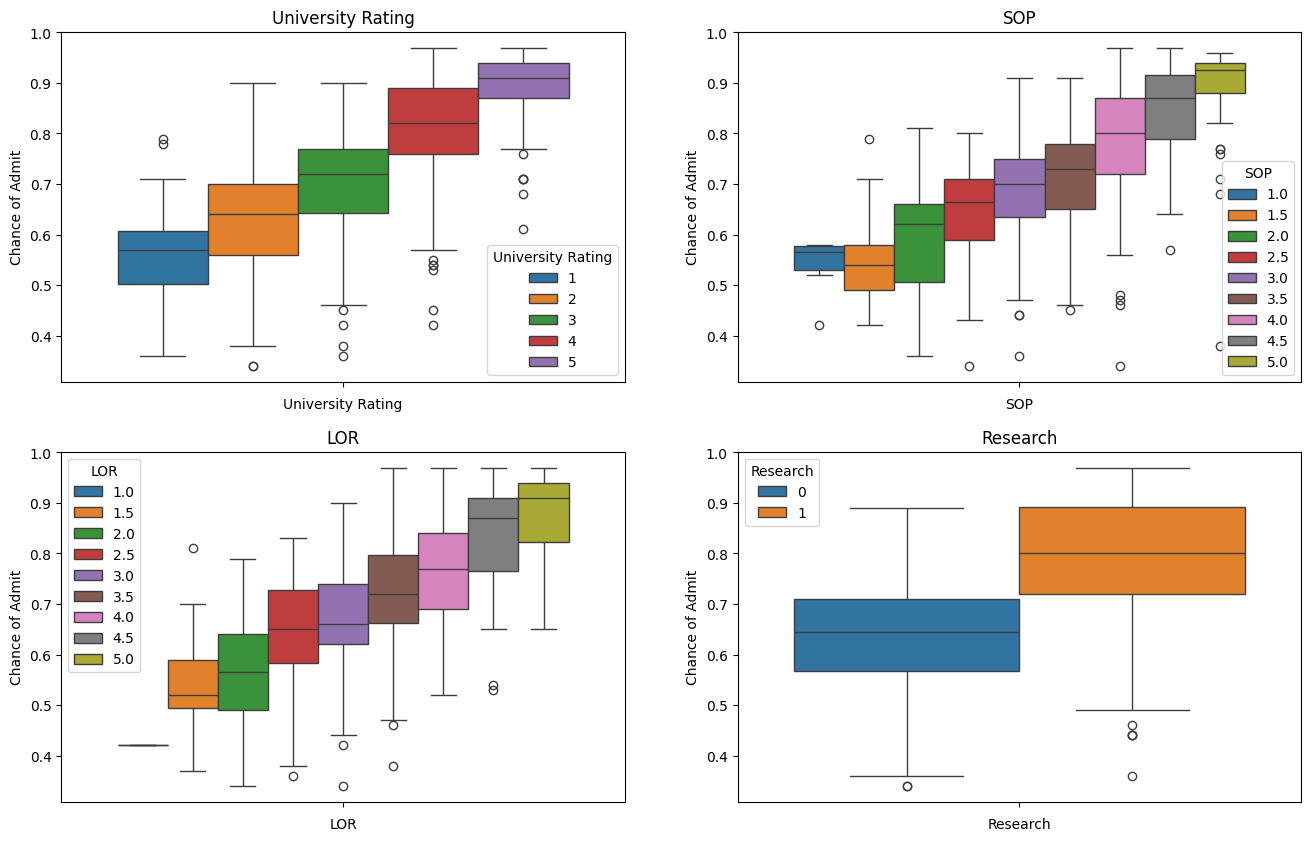

In [ ]:
#Boxplot
i=1
for col in cat_columns:
  plt.subplot(2,2,i)
  sns.boxplot(y=target,hue=df1[col])
  plt.title(f"{col}")
  plt.xlabel(f"{col}")
  i+=1
plt.show()

There little exterme outliers in University Rating , SOP , LOR , Research

Scatterplot for Numerical vs Numerical features

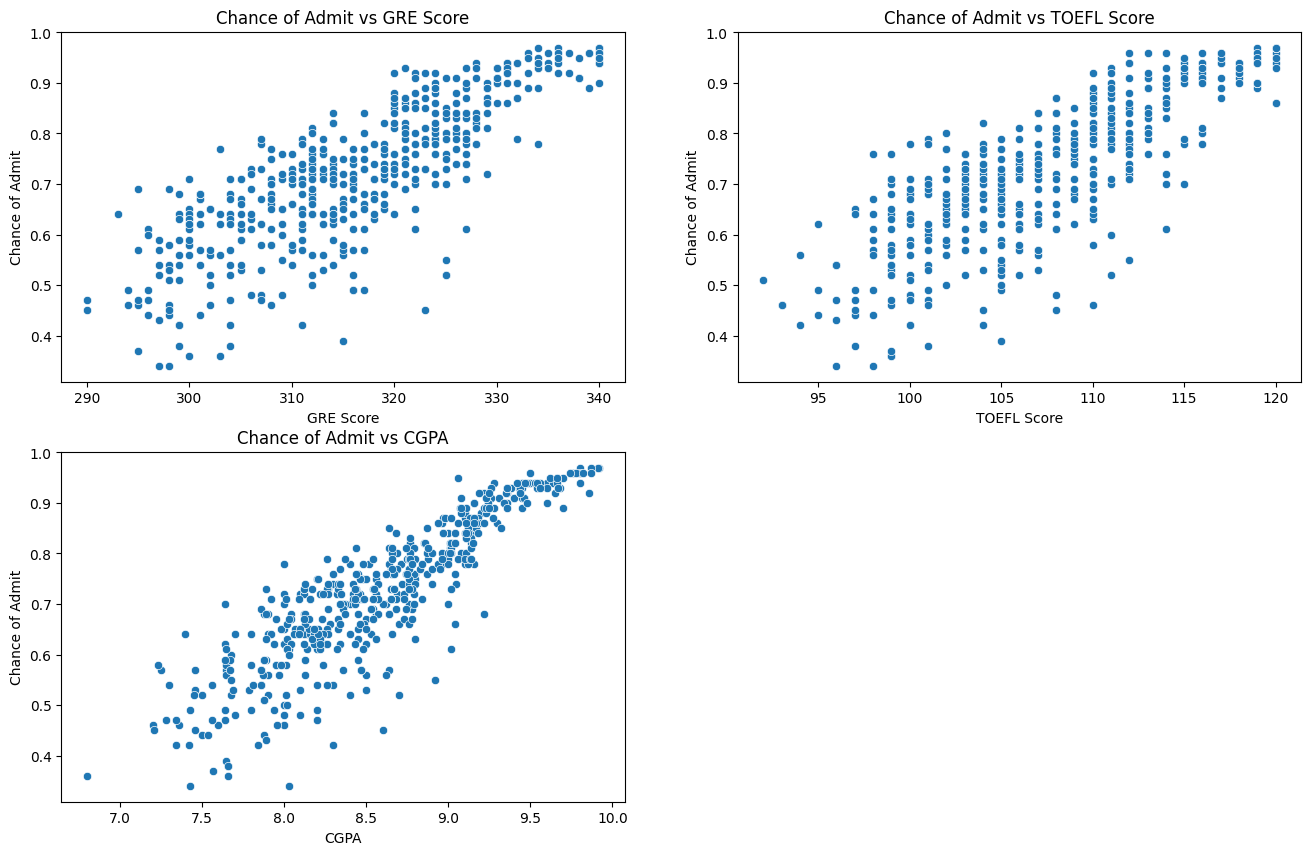

In [ ]:
#Scatterplot
i=1
for col in num_columns[:-1]:
  plt.subplot(2,2,i)
  sns.scatterplot(x=df1[col],y=target)
  plt.title(f'Chance of Admit vs {col}')
  plt.xlabel(f"{col}")
  plt.ylabel('Chance of Admit')
  i+=1
plt.show()

From Visulaization we concude that

GRE score and chance of admit are positively correlated - higher the GRE score more chances of admit

TOEFL score and chance of admit are positively correlated - higher the TOEFL score more chance of admit

CGPA and chance of admit are positively correlated - higher the CGPA then more chance of admit


Multivariate Analysis Visualization

Visualizing using barplot based on target vs categorical variable vs Research -yes or no

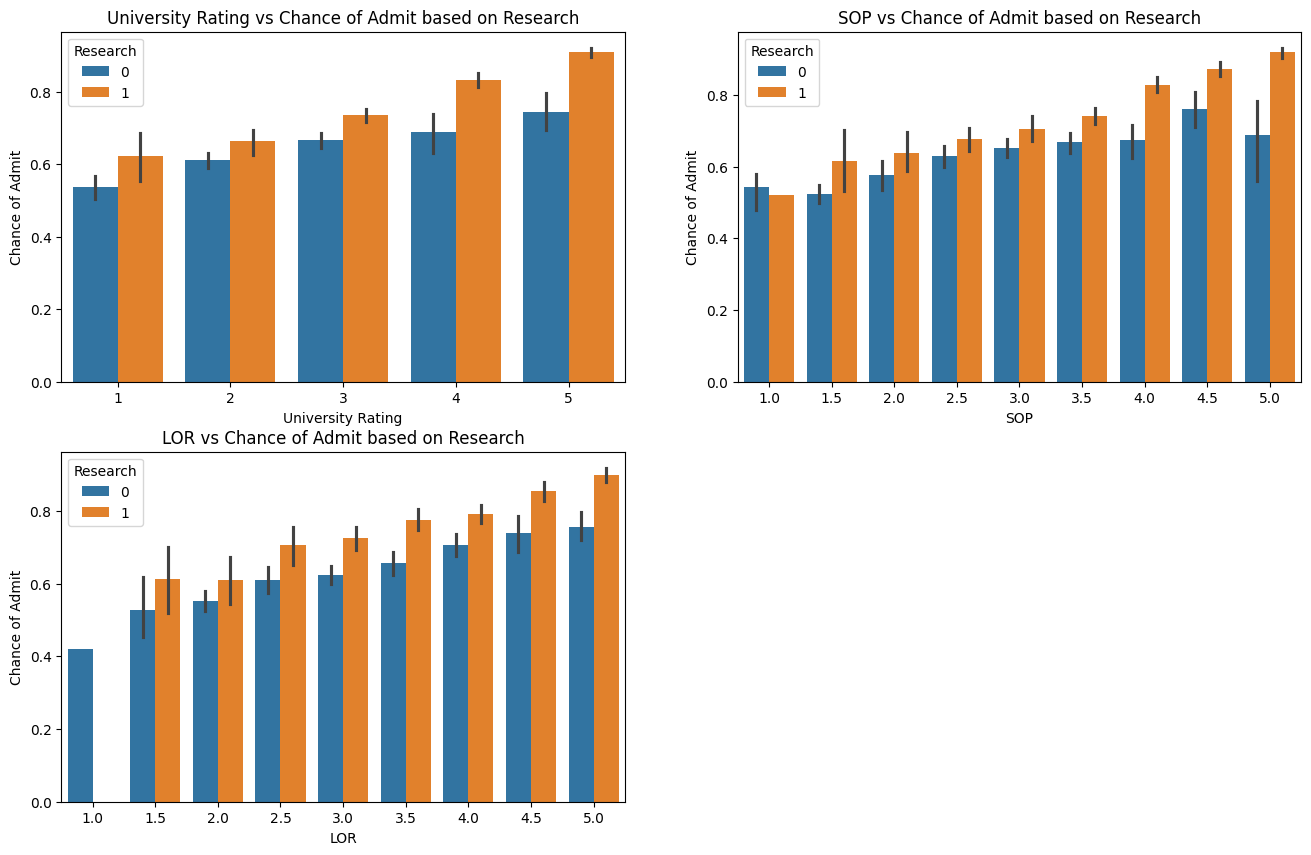

In [ ]:
#Barplot
i=1
for col in cat_columns[:-1]:
  plt.subplot(2,2,i)
  sns.barplot(x=df1[col],y=target,hue=df1['Research'])
  plt.title(f"{col} vs Chance of Admit based on Research")
  plt.xlabel(f"{col}")
  plt.ylabel('Chance of Admit')
  i+=1
plt.show()

Barplot visualization

When Research is 1 and Univeristy rating with 5 has high chance of admit

when Research is 1 and SOP with 5 has high chance of admit

when Research is 1 and LOR with 5 has high chance of admit

scatterplot for multivariate target vs numerical vs research

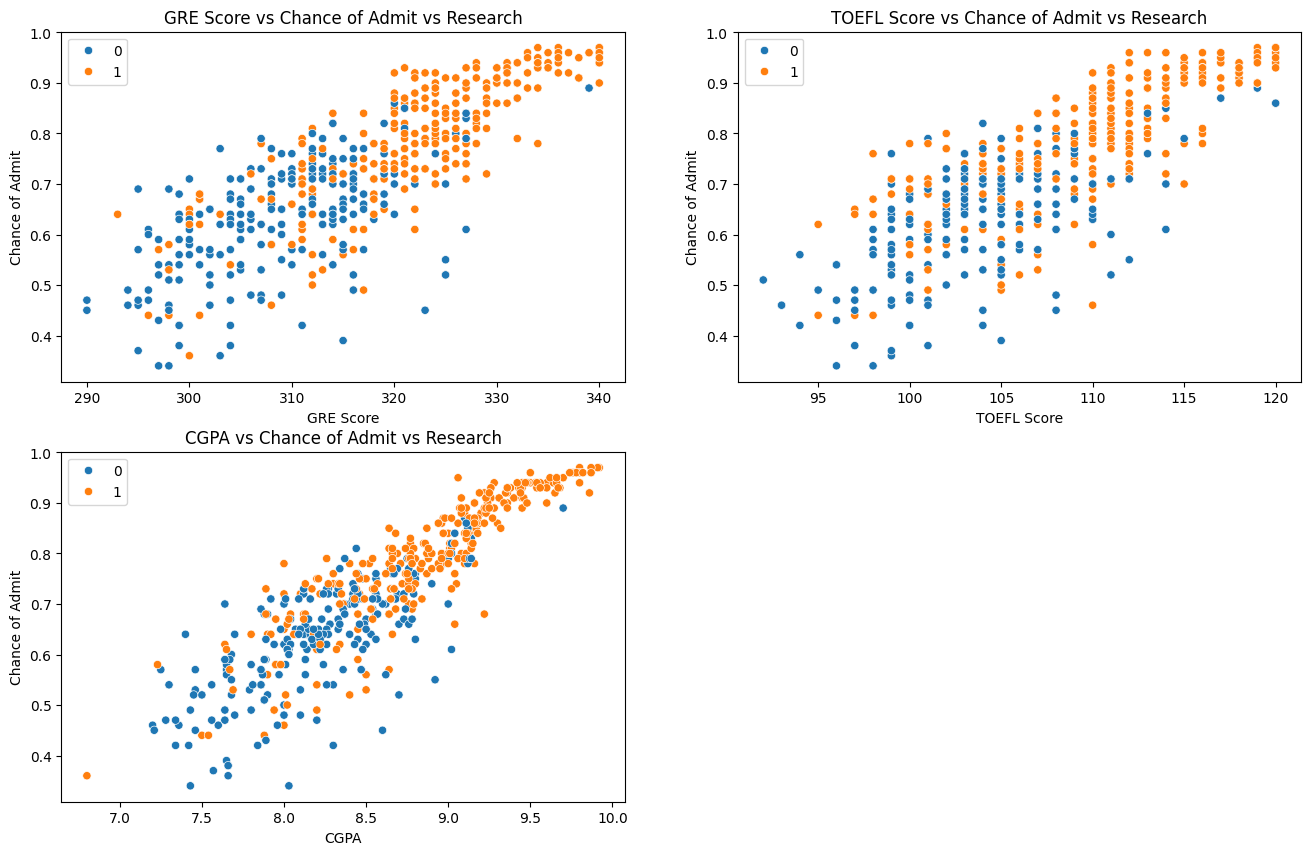

In [ ]:
#scatterplot
i=1
for col in num_columns[:-1]:
  plt.subplot(2,2,i)
  sns.scatterplot(x=df[col],y=target,hue=df1['Research'])
  plt.title(f'{col} vs Chance of Admit vs Research')
  plt.xlabel(f'{col}')
  plt.ylabel('Chance of Admit')
  plt.legend()
  i+=1
plt.show()

GRE score and chance of admit are positively correlated - based on Research is 1 then there is higher chance of admit

TOEFL score and chance of admit are positively correlated - based on Research is 1 the there is higher chance of admit

CGPA and chance of admit are positively correlated - based on Research is 1 the there is higher chance of admit

Scatterplot numerical variable vs Chance of admit based on university rating

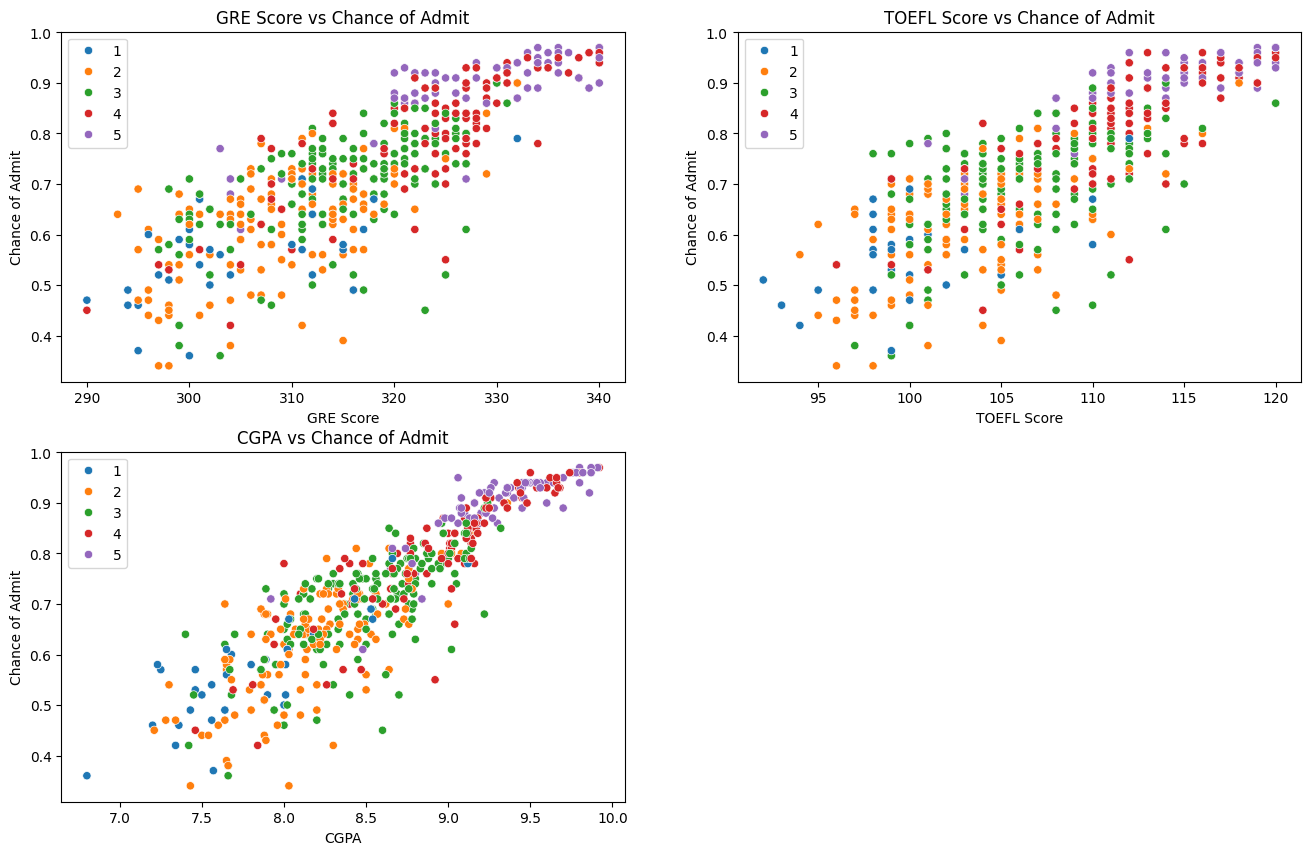

In [ ]:
#scatterplot
i=1
for col in num_columns[:-1]:
  plt.subplot(2,2,i)
  sns.scatterplot(x=df1[col],y=target,hue=df1['University Rating'])
  plt.title(f"{col} vs Chance of Admit")
  plt.xlabel(f'{col}')
  plt.ylabel(f'Chance of Admit')
  plt.legend()
  i+=1
plt.show()

GRE score and chance of admit are positively correlated - based on University Rating is 5 then there is higher chance of admit compared to other

TOEFL score and chance of admit are positively correlated - based on University Rating is 5 the there is higher chance of admit compared to other

CGPA and chance of admit are positively correlated - based on University is 5 the there is higher chance of admit compared to others

Boxplot Multi variate Analysis Categorical varuable vs target based on Research variable

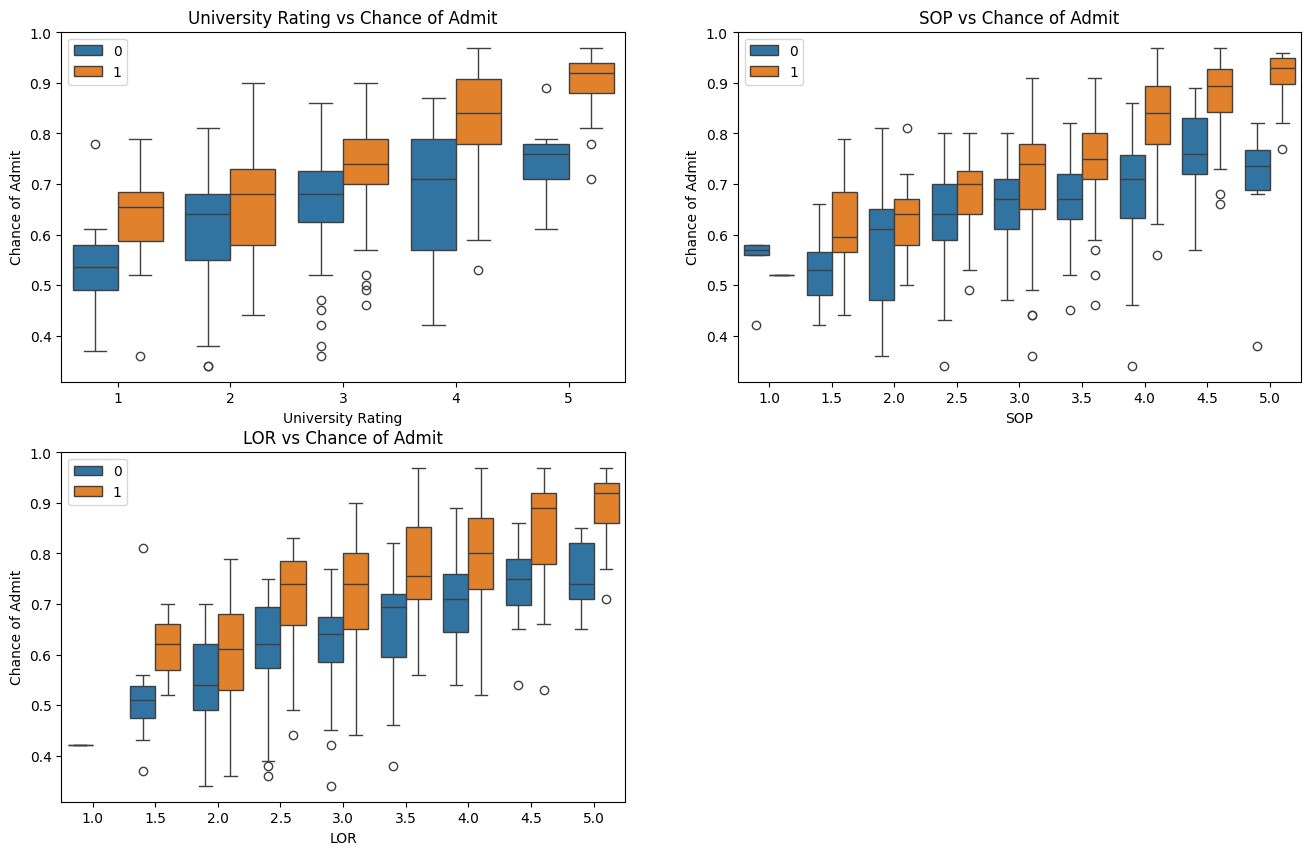

In [ ]:
#boxplot
i=1
for col in cat_columns[:-1]:
  plt.subplot(2,2,i)
  sns.boxplot(x=df1[col],y=target,hue=df1['Research'])
  plt.title(f'{col} vs Chance of Admit')
  plt.xlabel(f'{col}')
  plt.ylabel(f'Chance of Admit')
  plt.legend()
  i+=1
plt.show()

The above Visualization

The Median for most the plot with Research is 1 is higher than Research 0 expect LOR 1 has not research done and for SOP 1 also no research done

Heatmap

<Axes: >

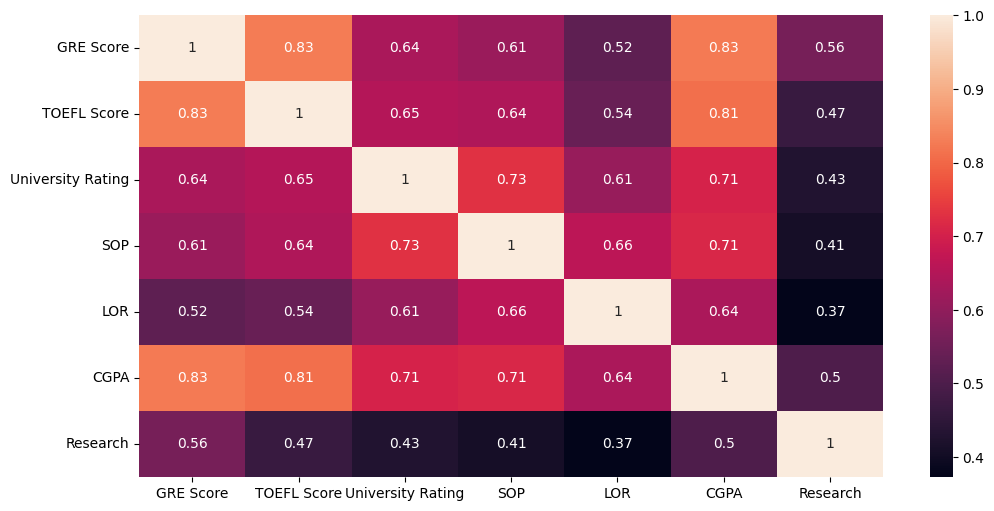

In [ ]:
plt.figure(figsize=(12,6))
sns.heatmap(df.iloc[:,:-1].select_dtypes(['int','float']).corr(),annot=True)

The correaltion between TOEFL score and GRE score is high which might lead to multi collinearity

The correlation CGPA and TOEFL score is high which might lead to multi collinearity

The correlation CGPA and GRE Score is high which migh lead to multi collinearity

#Data Preprocessing

Duplicate value check


In [ ]:
df.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
if df.duplicated().sum()==0:
  print("No Duplicates Found")
else:
  print("Duplicates Found")

No Duplicates Found


There are no duplicates found in the dataset

Missing value treatment

In [ ]:
df.isnull().sum()

,0
GRE Score,0
TOEFL Score,0
University Rating,0
SOP,0
LOR,0
CGPA,0
Research,0
Chance of Admit,0


There are no null or Missing Values in DataFrame

Outlier treatment

In [ ]:
df.shape

(500, 8)

In [ ]:
for col in df.columns:
  Q1=df[col].quantile(0.25)
  Q3=df[col].quantile(0.75)

  IQR=Q3-Q1

  lower=Q1-1.5*IQR
  upper=Q3+1.5*IQR
  df=df.loc[(df[col]>=lower)&(df[col]<=upper)]

In [ ]:
df.shape

(497, 8)

By using Inter Quartile Range (IQR) method removing the Outlier
IQR method :


           Q1=25 percentile of data
           Q3=75 percentile of data
           IQR=Q3-Q1

           lower bound= Q1-1.5*IQR
           upper bound= Q3+1.5*IQR



Feature engineering and Data preparation for modeling


In [ ]:
df.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65


We have Dataframe after Removing Outliers and filling Missing values

Preparing Data for Model

we use Train test split to split data into train and test data for training the model and test data

Standard scaler is used for scaling data :

                                          x_scaled=(x-mu)/std

where mu(mean)=0 and standard deviation=1


standard scaling is used to reduce the bias of model towards data which has higher values ranges , so by standard scaling we prevent the model from being biased towards data

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
X=df.drop(columns='Chance of Admit')
y=df[['Chance of Admit']]
train_x,test_x,train_y,test_y=train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
train_x.shape,train_y.shape

((397, 7), (397, 1))

In [ ]:
test_x.shape,test_y.shape

((100, 7), (100, 1))

Split the data into Train and Test data by 80% Train and 20% Test data

In [ ]:
scaler=StandardScaler()
train_x_scaled=scaler.fit_transform(train_x)
test_x_scaled=scaler.fit_transform(test_x)
train_x_scaled=pd.DataFrame(train_x_scaled,columns=train_x.columns)
test_x_scaled=pd.DataFrame(test_x_scaled,columns=test_x.columns)

In [ ]:
train_x_scaled.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research
0,-0.109369,-0.912490,-0.135635,-1.411440,-0.519819,-1.992742,-1.161513
1,0.070050,0.734888,-0.135635,0.609630,0.017598,0.103614,-1.161513
2,-0.019659,0.405413,-0.135635,0.609630,1.092431,0.829911,0.860946
3,0.877439,1.229102,0.732868,0.104363,0.555015,0.879431,-1.161513
4,-0.109369,0.405413,-0.135635,0.104363,0.555015,-0.077960,-1.161513


In [ ]:
test_x_scaled.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research
0,0.441783,-0.723657,0.009245,-0.835940,-1.190056,-0.199249,-1.040833
1,-0.005366,0.322594,0.933785,1.228110,0.543035,0.976934,0.960769
2,-0.184225,0.148219,-0.915294,-0.835940,-0.034662,-0.374799,-1.040833
3,1.336080,2.240721,0.933785,1.228110,1.120732,1.187594,0.960769
4,-0.363085,-0.374907,0.009245,-1.351953,-0.034662,-0.199249,-1.040833


In [ ]:
print('shape of Train_x_scaled :',train_x_scaled.shape)
print('shape of Test_x_scaled :',test_x_scaled.shape)

shape of Train_x_scaled : (397, 7)
shape of Test_x_scaled : (100, 7)


Data Frame has been scaled using StandardScaler

#Model building

Build the Linear Regression model and comment on the model statistics


Linear Regression is a supervised machine learning algorithm that is used to perform Regression tasks ,it models linear relationship between input features X and target variable y to predict the real continous values

y_predicted=w1*x1+w2*x2+w3*x3.....+w0

where :  w1,w2,w3.. are coeffecients or weights
         w0 is bias  
         x1,x2,x3.. are input features

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
model=LinearRegression()
model.fit(train_x_scaled,train_y)

LinearRegression()

In [ ]:
y_predict=model.predict(test_x_scaled)
y_predict

array([[0.67741119],
       [0.83034647],
       [0.68430435],
       [0.91938913],
       [0.68230767],
       [0.76505162],
       [0.672803  ],
       [0.61456331],
       [0.62186597],
       [0.74682855],
       [0.81437785],
       [0.70623261],
       [0.62063719],
       [0.98624393],
       [0.69049042],
       [0.57774163],
       [0.55464841],
       [0.62343545],
       [0.86116387],
       [0.69144765],
       [0.7035041 ],
       [0.58415825],
       [0.6542107 ],
       [0.9269017 ],
       [0.7384212 ],
       [0.54825712],
       [0.85178861],
       [0.62364372],
       [0.60469801],
       [0.85570193],
       [0.88962479],
       [0.801745  ],
       [0.92261943],
       [0.67758434],
       [0.7609826 ],
       [0.45864156],
       [0.85475033],
       [0.78084104],
       [0.68592449],
       [0.81451269],
       [0.6481971 ],
       [0.56505344],
       [0.96815667],
       [0.57455693],
       [0.99084821],
       [0.86811273],
       [0.77647714],
       [0.842

In [ ]:
print('Train score Accuracy : ',model.score(train_x_scaled,train_y)*100)
print('Test score Accuracy : ',model.score(test_x_scaled,test_y)*100)

Train score Accuracy :  82.61392753723374
Test score Accuracy :  74.64867614802434


Train accuracy which is 82.6 and test accuracy is 74.6

here the accurcay is very low for test and train score is overfitting

we have check with lasso and ridge by using regularization parameter

Display model coefficients with column names

In [ ]:
model_coeffecients=pd.DataFrame({'Features':train_x.columns,'coef_':model.coef_.flatten()})
model.coeffecients=model_coeffecients.sort_values(by='coef_',ascending=False)
model.coeffecients

,Features,coef_
5,CGPA,0.068175
0,GRE Score,0.022374
1,TOEFL Score,0.018305
4,LOR,0.016541
6,Research,0.011178
3,SOP,0.005019
2,University Rating,0.002383


In [ ]:
print('Intercept : ',model.intercept_)

Intercept :  [0.72984887]


Use Linear Regression OLS from and explain the results

In [ ]:
import statsmodels.api as sm

In [ ]:
train_x_scaled.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research
0,-0.109369,-0.912490,-0.135635,-1.411440,-0.519819,-1.992742,-1.161513
1,0.070050,0.734888,-0.135635,0.609630,0.017598,0.103614,-1.161513
2,-0.019659,0.405413,-0.135635,0.609630,1.092431,0.829911,0.860946
3,0.877439,1.229102,0.732868,0.104363,0.555015,0.879431,-1.161513
4,-0.109369,0.405413,-0.135635,0.104363,0.555015,-0.077960,-1.161513


In [ ]:
train_y.head()

,Chance of Admit
56,0.64
228,0.71
281,0.80
487,0.79
221,0.75


OLS - One least square is linear regression form

where we have to add bias constant explicilty to the train x data


In [ ]:
train_x_sm=sm.add_constant(train_x_scaled)
train_x_sm.head()

,const,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research
0,1.0,-0.109369,-0.912490,-0.135635,-1.411440,-0.519819,-1.992742,-1.161513
1,1.0,0.070050,0.734888,-0.135635,0.609630,0.017598,0.103614,-1.161513
2,1.0,-0.019659,0.405413,-0.135635,0.609630,1.092431,0.829911,0.860946
3,1.0,0.877439,1.229102,0.732868,0.104363,0.555015,0.879431,-1.161513
4,1.0,-0.109369,0.405413,-0.135635,0.104363,0.555015,-0.077960,-1.161513


In [ ]:
#converting Dataframe to array
# Model OLS
train_y=np.array(train_y).flatten()
model_sm=sm.OLS(train_y,train_x_sm).fit()
print(model_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.826
Model:                            OLS   Adj. R-squared:                  0.823
Method:                 Least Squares   F-statistic:                     264.1
Date:                Mon, 08 Sep 2025   Prob (F-statistic):          1.67e-143
Time:                        08:40:46   Log-Likelihood:                 566.95
No. Observations:                 397   AIC:                            -1118.
Df Residuals:                     389   BIC:                            -1086.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.7298      0.00

from above model we see that

 R-square is 0.826

 Adjusted R square is 0.823


#Testing the assumptions of the linear regression model

1. Linearity - There should be linear relationship between input independent feature X  and dependent target variable y

2.  No Multi collinearity - There should be no correlation or little correlation between input independent features x

3. Normality of Residuals - Distribution of residuals must be in normal distribution

4. Homoskedascity : The residual should have constant variance across all predicted values

5.Auto correlation : The next errors made by model should be independent of error made by previous model

Multi collinearity check by VIF score:  

Muti collinearity : The correaltion between independent input features x

Multi collinearity makes interpretabilty difficult and unstable coeffecients

For Linear regression we have to remove Multi collinearity by using Variance inflation factor


            VIF=1/(1-R**2)

If R is 1 then High collinearity

if R is 0 then VIF=1 There is no collinearity

Multi collinearity affects the interpretability of coeffecients which helps understanding which input feature X has highest impact or weightage

Variance inflation factor VIF

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [ ]:
rsquare_adj=0.85
VIF_1=5
removed_features=[]
cols=train_x_scaled.columns.to_list()
while True:
  x_t=train_x_scaled[cols]
  vif=pd.DataFrame({'Features':x_t.columns})
  vif['VIF']=[variance_inflation_factor(x_t.values,i) for i in range(x_t.shape[1])]
  vif=vif.sort_values(by='VIF',ascending=False)

  x_t_sm=sm.add_constant(x_t)
  model_sm=sm.OLS(train_y,x_t_sm).fit()

  if model_sm.rsquared_adj<=rsquare_adj or vif.iloc[0]['VIF']<=VIF_1:
    print(vif)
    print()
    print("Removed features", removed_features)
    break

  remove1=vif.iloc[0]['Features']
  removed_features.append(remove1)
  cols.remove(remove1)

            Features       VIF
5               CGPA  4.982471
0          GRE Score  4.344912
1        TOEFL Score  3.646516
3                SOP  2.932950
2  University Rating  2.699182
4                LOR  2.114230
6           Research  1.505431

Removed features []


All the features VIF is less than 5 indicates they have little or no multi collinearity , so features are removed

Mean of residuals : using OLS


In [ ]:
import statsmodels.api as sm

In [ ]:
train_x_sm=sm.add_constant(train_x_scaled)
model_sm=sm.OLS(train_y,train_x_sm).fit()
print(model_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.826
Model:                            OLS   Adj. R-squared:                  0.823
Method:                 Least Squares   F-statistic:                     264.1
Date:                Mon, 08 Sep 2025   Prob (F-statistic):          1.67e-143
Time:                        08:40:46   Log-Likelihood:                 566.95
No. Observations:                 397   AIC:                            -1118.
Df Residuals:                     389   BIC:                            -1086.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.7298      0.00

mean residuals

In [ ]:
print("Mean residuals : ",model_sm.resid.mean())

Mean residuals :  -5.44624519006925e-16


Mean residual is closer to zero

Linearity of variables (no pattern in residual plot)


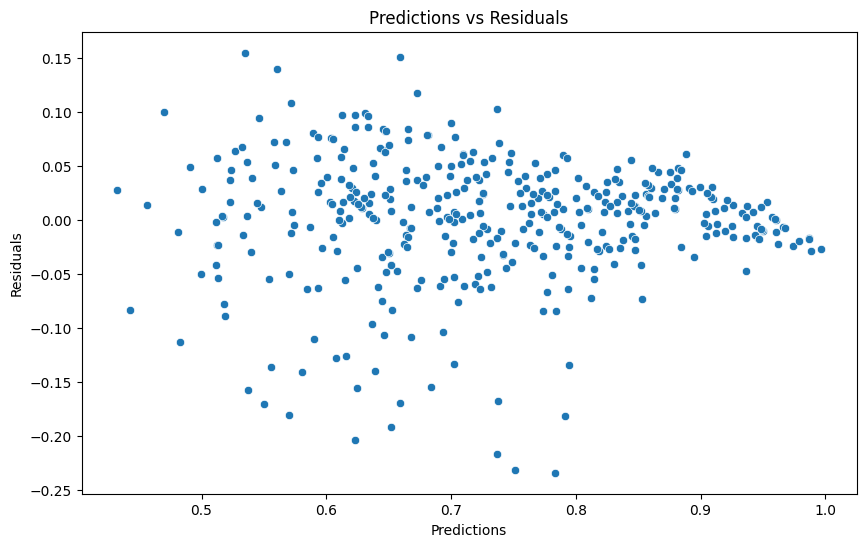

In [ ]:
residuals=model_sm.resid
predictions=model_sm.fittedvalues
plt.figure(figsize=(10,6))
sns.scatterplot(x=predictions,y=residuals)
plt.title('Predictions vs Residuals')
plt.xlabel('Predictions')
plt.ylabel('Residuals')
plt.show()

There is no funnel shaped

The residuals are concentrated at 0

This is Homoskedascity

Test for Homoskedascity:

The variance of residuals is same across all the predictions

To find if it is Homoskedascity by using goldfeldquandt

Null Hypothesis : Homoskedascity

Alternate Hyposthesis : Heteroskedascity

significance_level=0.05

In [ ]:
from statsmodels.stats.diagnostic import het_goldfeldquandt

In [ ]:
t_stats,p,h=het_goldfeldquandt(model_sm.resid,model_sm.model.exog)

In [ ]:
print("PValue: ",p)
if p>0.05:
  print("Null Hypothesis")
  print("Homoskedascity")
else:
  print("Alternate Hypothesis")
  print("Heteroskedascity")

PValue:  0.44547168193266157
Null Hypothesis
Homoskedascity


So it is Homoskedascity the assumption linear regression is True

Normality of residuals:

There should be normal distribution of errors or rwsiduals

error=y-y_prediction

In [ ]:
residuals=model_sm.resid
residuals

,0
0,0.094145
1,-0.031977
2,-0.023839
3,-0.040402
4,0.024094
...,...
392,-0.016019
393,0.016978
394,0.040580
395,-0.062176


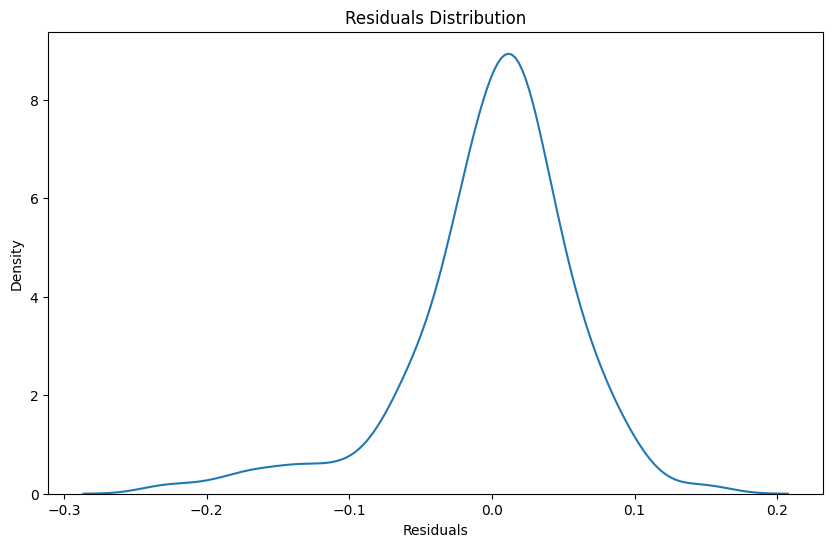

In [ ]:
plt.figure(figsize=(10,6))
sns.kdeplot(residuals)
plt.title('Residuals Distribution')
plt.xlabel('Residuals')
plt.show()

shapiro wilkis test

In [ ]:
from scipy.stats import shapiro

In [ ]:
t_stat,p=shapiro(residuals)
print("p value",p)
if p>0.01:
  print('Normal Distribution')
else:
  print("Not Normal Distribution")

p value 8.046808294911777e-13
Not Normal Distribution


In [ ]:
from statsmodels.graphics.gofplots import qqplot

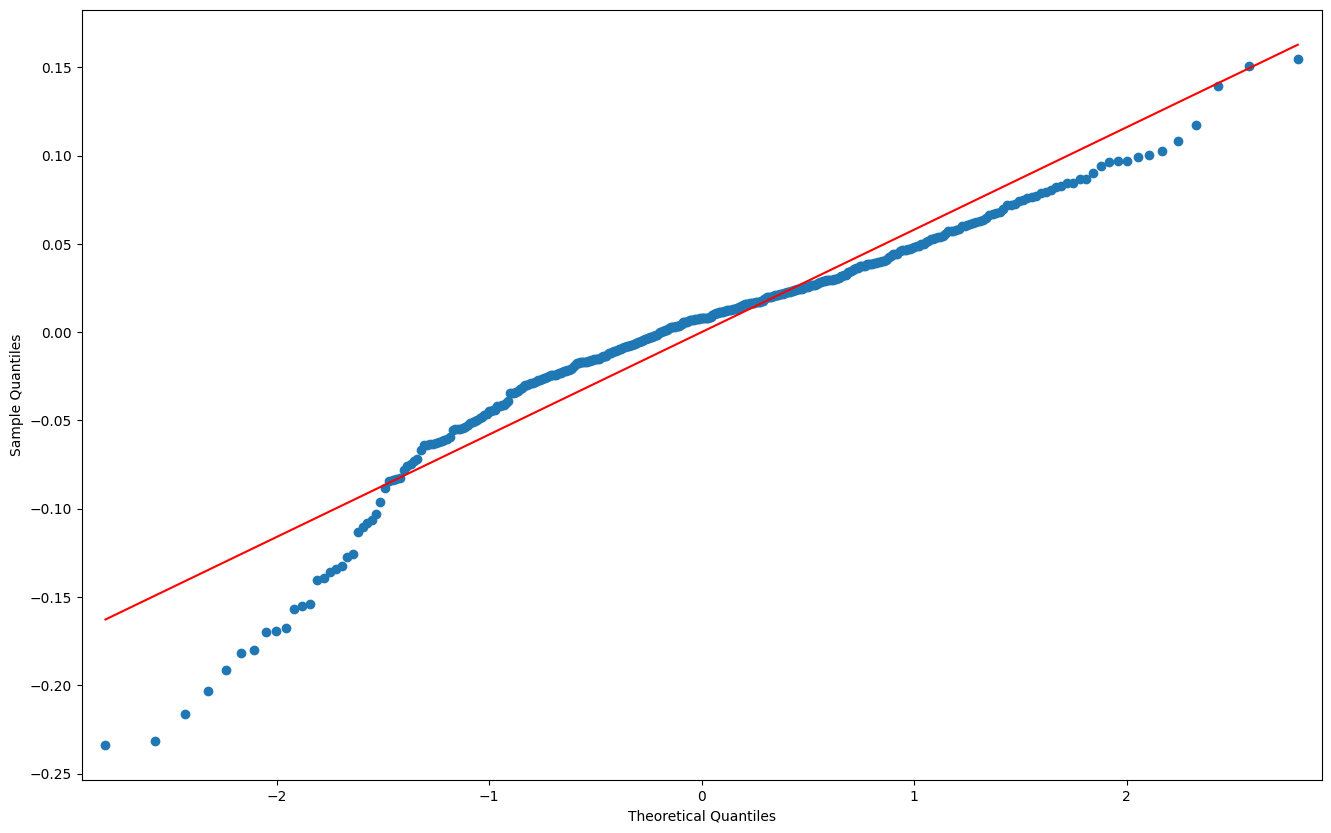

In [ ]:
qqplot(residuals,line='s')
plt.show()

All the assumptions for Linear Regression have met successfully, although shapiro-wilk test failed proving normal distribution of the data, the Q-Q plot shows not a large deviation from 0.


Linear Regression is supervised machine learning algorithm , it models relationship between input independent variable with target varibale y ,it predicts continous real values

         Y_predicted=w1*x1+w2*x2+w3*x3....wn*xn+w0

         where w-> weights or coefficients
               w0->bias or intercept term
               Y_predicted-> value predicted

Loss function for Linear Regression is

                              L=min(1/m*summation(y-y_predicted)**2)




$L = \frac{1}{m} \sum_{i=1}^{m} (y_i - \hat{y}_i)^2$


## Gradient Descent for Linear Regression

**Loss function (MSE):**

$$
L(w, b) = \frac{1}{m} \sum_{i=1}^{m} (y_i - \hat{y}_i)^2
$$

**Gradients:**

- With respect to weight \(w\):

$$
\frac{\partial L}{\partial w} = -\frac{2}{m} \sum_{i=1}^{m} (y_i - \hat{y}_i) \cdot x_i
$$

- With respect to bias \(b\):

$$
\frac{\partial L}{\partial b} = -\frac{2}{m} \sum_{i=1}^{m} (y_i - \hat{y}_i)
$$

**Gradient Descent Updates:**

$$
w := w - \alpha \frac{\partial L}{\partial w}
$$

$$
b := b - \alpha \frac{\partial L}{\partial b}
$$

Where:
- \( \alpha \) = learning rate
- \( y_i - \hat{y}_i \) = residual (error)
- \( m \) = number of samples


In [ ]:
df.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65


In [ ]:
X=df.drop(columns='Chance of Admit')
y=df['Chance of Admit']

In [ ]:
train_x,test_x,train_y,test_y=train_test_split(X,y,test_size=0.2,random_state=1)
print(train_x.shape,train_y.shape)
print(test_x.shape,test_y.shape)

(397, 7) (397,)
(100, 7) (100,)


In [ ]:
scaler=StandardScaler()
train_x_scaled=scaler.fit_transform(train_x)
test_x_scaled=scaler.transform(test_x)

In [ ]:
linear_model=LinearRegression()
linear_model.fit(train_x_scaled,train_y)
y_predictions=linear_model.predict(test_x_scaled)

In [ ]:
print("Train score : ",linear_model.score(train_x_scaled,train_y))
print("Test score : ",linear_model.score(test_x_scaled,test_y))

Train score :  0.8234060990536943
Test score :  0.8153548390017229


#Metrics checked - MSE,MAE, RMSE, R2, Adj R2


Mean squared Error:

Mean squred error is average square of difference between values and predicted values

mean squared error penalizes large errors heavily

mean squared error is sensitive to outliers

$$
MSE = \frac{1}{m} \sum_{i=1}^{m} (y_i - \hat{y}_i)^2
$$




In [ ]:
from sklearn.metrics import mean_squared_error

Mean Absolute Error:

Mean absolute error is absolute difference between values and predicted values

Mean absolute error penalizes all errors equally

mean absolute error is not sensitive to outliers


$$
MAE = \frac{1}{m} \sum_{i=1}^{m} |y_i - \hat{y}_i|
$$


In [ ]:
from sklearn.metrics import mean_absolute_error

Root Mean Squared Error:

Root Mean Squared Error is root square of averaged square of difference between real values and predicted values

RMSE penalizes larger error more than MAE

RMSE is in same units as target variable

RMSE is sensitive to outliers like MSE


$$
RMSE = \sqrt{\frac{1}{m} \sum_{i=1}^{m} (y_i - \hat{y}_i)^2}
$$


In [ ]:
def performance(actual,predicted):
  print("MSE : ",round(mean_squared_error(actual,predicted),3))
  print("MAE : ",round(mean_absolute_error(actual,predicted),3))
  print("RMSE : ",round(mean_squared_error(actual,predicted)**0.5,3))

In [ ]:
print("Train Performance")
performance(train_y,linear_model.predict(train_x_scaled))
print()
print("Test Performance")
performance(test_y,linear_model.predict(test_x_scaled))

Train Performance
MSE :  0.003
MAE :  0.042
RMSE :  0.059

Test Performance
MSE :  0.003
MAE :  0.042
RMSE :  0.058


Since RMSE is closer to MAE in both Train and Test perfromance indicates the there are no extreme outliers

R- Square:

R-Square measures how well the the model explains variance of target variable comapred to mean model

$R^2 = 1 - \frac{SS_{res}}{SS_{tot}}$

$SS_{res} = \sum_{i=1}^m (y_i - \hat{y}_i)^2$

$SS_{tot} = \sum_{i=1}^m (y_i - \bar{y})^2$

$R^2$=1  Model is best

$R^2$=0 Model is similar to mean model

$R^2$<0 Model is worse than mean model

In [ ]:
def r_square(actual,predicted):
  y_mean=actual.mean()
  ss_res=np.sum((actual-predicted)**2)
  ss_total=np.sum((actual-y_mean)**2)
  R_2=1-(ss_res/ss_total)
  return R_2

In [ ]:
print('R^2 for Train Data :',r_square(train_y,linear_model.predict(train_x_scaled)))
print('R^2 for Test Data  :',r_square(test_y,linear_model.predict(test_x_scaled)))

R^2 for Train Data : 0.8234060990536943
R^2 for Test Data  : 0.8153548390017229


R square is for both Train and Test Data is higher so The model explains variance of target variable compared to mean model

Adjusted R square:

Adjusted R square is modified version of R square

Adj R square increases when relevant feature is added

Adj R square decreases or remains same when irrelevant feature is added

                     Adjusted_R_Square= 1-((1-R_square)*(m-1)/(m-k-1))

where m is no of rows

where k is no of columns

In [ ]:
def rsquared_adj(r_sq,x):
  adj_r=1-((1-r_sq)*(x.shape[0]-1)/(x.shape[0]-x.shape[1]-1))
  return adj_r

In [ ]:
print("Train Adjusted R square :",rsquared_adj(r_square(train_y,linear_model.predict(train_x_scaled)),train_x_scaled))
print("Test Adjusted R square  :",rsquared_adj(r_square(test_y,linear_model.predict(test_x_scaled)),test_x_scaled))

Train Adjusted R square : 0.8202283167744548
Test Adjusted R square  : 0.8013057506648975


Adjusted R square is very closer for both Train and Test Data

There is another regression called Polynomial Regression where when relationship between features and target variable slight curve then this type of Linear Regression is applied on polynomialy transformed features

Since our features and perfectly in linear relationship with the target variable no need of applying polynomial features

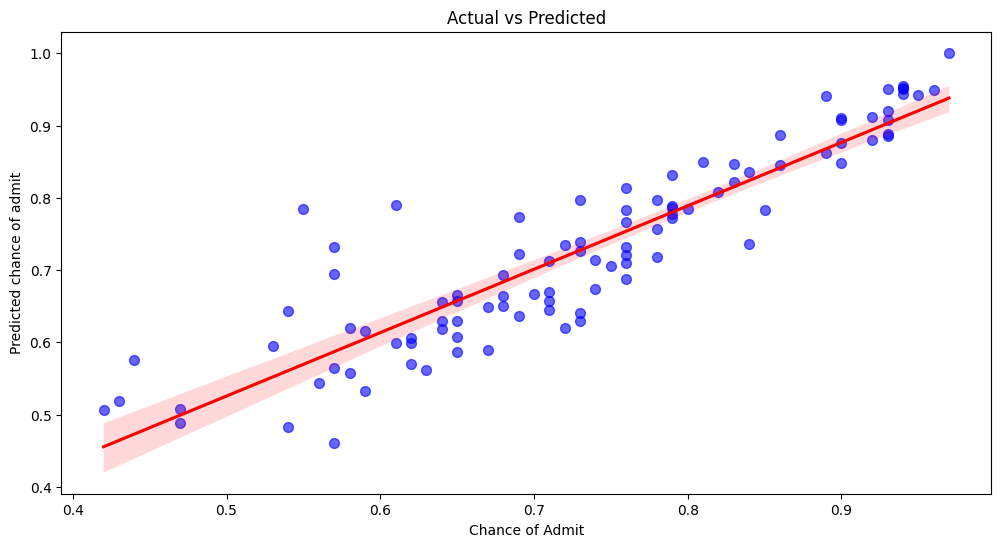

In [ ]:
plt.figure(figsize=(12,6))
sns.regplot(x=test_y,y=linear_model.predict(test_x_scaled),scatter_kws={'alpha': 0.6, 's': 50, 'color': 'blue'},line_kws={'color': 'red'})
plt.title("Actual vs Predicted")
plt.xlabel("Chance of Admit")
plt.ylabel("Predicted chance of admit")
plt.show()

#Regularization

Regularization: To prevent the overfitting

overfitting when Train data is fit perfectly but Test data is not able to generalize

Lasso Regularization is a type of linear regression that adds l1 regularization,it adds penalty term that is proportional to absolute coeffecients of model , Lasso regularization reduces irrelevant features coeffecients to zero

It can be used for feature selection ,if dimension is high

$L = \frac{1}{m}\sum_{i=1}^m (y_i - \hat{y}_i)^2 + \alpha \sum_{j=1}^n |w_j|$

$\alpha\$  -> Regularization strength

$|w_j|$ -> penalty term

In [ ]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
lasso_model=Lasso(alpha=0.1)
lasso_model.fit(train_x_scaled,train_y)

Lasso(alpha=0.1)

In [ ]:
print("Train Accuracy :",lasso_model.score(train_x_scaled,train_y))
print("Test Accuracy  :",lasso_model.score(test_x_scaled,test_y))

Train Accuracy : 0.26775893767310643
Test Accuracy  : 0.28699019594509156


Train and Test Accuracy is very low let's change alpha value

In [ ]:
param={'alpha':[0.0001,0.001,0.01,0.1,0.5,0.8,1,10]}
rd=RandomizedSearchCV(estimator=Lasso(),param_distributions=param,cv=5,n_iter=10)
rd.fit(train_x_scaled,train_y)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 8 is smaller than n_iter=10. Running 8 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


RandomizedSearchCV(cv=5, estimator=Lasso(),
                   param_distributions={'alpha': [0.0001, 0.001, 0.01, 0.1, 0.5,
                                                  0.8, 1, 10]})

In [ ]:
rd.score(test_x_scaled,test_y)

0.8154497039884835

In [ ]:
lasso_model=rd.best_estimator_
lasso_model.fit(train_x_scaled,train_y)
train_pred=lasso_model.predict(train_x_scaled)
test_pred=lasso_model.predict(test_x_scaled)

In [ ]:
print('Train')
performance(train_y,train_pred)
print()
print('Test')
performance(test_y,test_pred)

Train
MSE :  0.003
MAE :  0.042
RMSE :  0.059

Test
MSE :  0.003
MAE :  0.042
RMSE :  0.058


For both Train and Test RMSE and MAE are closer makes that there is no extreme outliers

R square measures how well the model explains variance compared to mean model

In [ ]:
def r_square(y,y_predicted):
  ss_res=np.sum((y-y_predicted)**2)
  ss_total=np.sum((y-y.mean())**2)
  score=1-(ss_res/ss_total)
  return score

In [ ]:
print("Train R_sqaured :",r_square(train_y,train_pred))
print()
print("Test R_squared  :",r_square(test_y,test_pred))

Train R_sqaured : 0.8234052198415014

Test R_squared  : 0.8154497039884835


Adjusted R modified version of R square , increases when added relevant feature , decreases or remains same when irrelevant features are added

In [ ]:
def rsquared_adj(r_score,X):
  adj=1-((1-r_score)*(len(X)-1)/(len(X)-X.shape[1]-1))
  return adj

In [ ]:
print("Train Adjusted R square :",rsquared_adj(r_square(train_y,train_pred),train_x_scaled))
print("Test Adjusted R square  :",rsquared_adj(r_square(test_y,test_pred),test_x_scaled))

Train Adjusted R square : 0.8202274217409629
Test Adjusted R square  : 0.8014078336397812


From the Adjusted score we can conclude that Train  R sqaure and Adjusted R sqaure are similar

But Test Adjusted R sqaure reduces comapred to R square

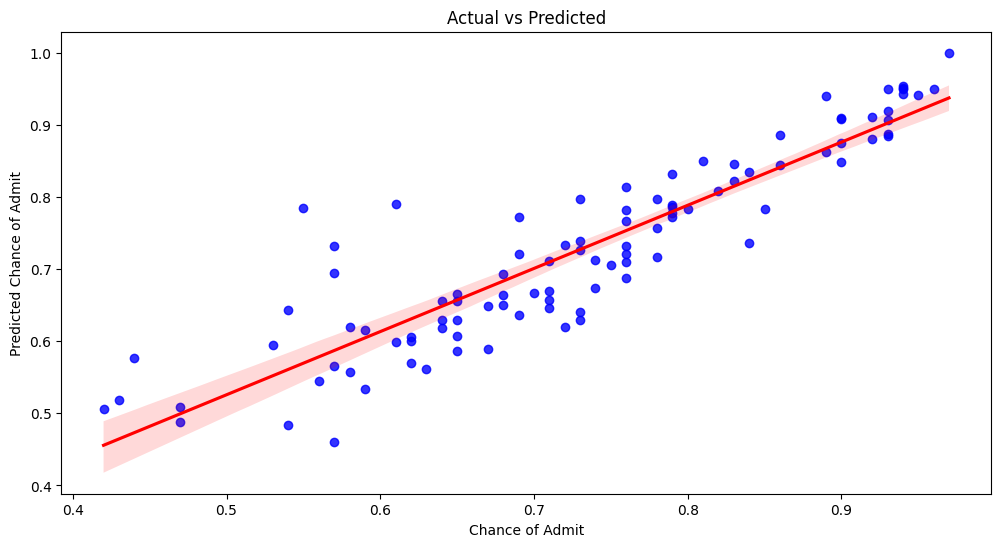

In [ ]:
plt.figure(figsize=(12,6))
sns.regplot(x=test_y,y=lasso_model.predict(test_x_scaled),scatter_kws={'color':'blue'},line_kws={'color':'red'})
plt.title('Actual vs Predicted')
plt.xlabel('Chance of Admit')
plt.ylabel('Predicted Chance of Admit')
plt.show()

Ridge Regularization

Ridge Regularization is type of linear Regression adds l2 regularization,it adds penalty term and that is proportional to squared coeffecients ,Ridge regularization reduces coeffecients closer to zero but not zero

This is effective when all the features are important


$L = \frac{1}{m}\sum_{i=1}^m (y_i - \hat{y}_i)^2 + \alpha \sum_{j=1}^n w_j^2$  

$\alpha$ -> Regularization strength  

$w_j^2$ -> Penalty term

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
ridge_model=Ridge(alpha=0.01)
ridge_model.fit(train_x_scaled,train_y)
print("R_square:",ridge_model.score(test_x_scaled,test_y))

R_square: 0.8153562101479523


In [ ]:
params={'alpha':[0.0001,0.001,10,15,16,17,18,20]}
rd=RandomizedSearchCV(estimator=Ridge(),param_distributions=params,cv=10,n_iter=15)
rd.fit(train_x_scaled,train_y)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 8 is smaller than n_iter=15. Running 8 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


RandomizedSearchCV(cv=10, estimator=Ridge(), n_iter=15,
                   param_distributions={'alpha': [0.0001, 0.001, 10, 15, 16, 17,
                                                  18, 20]})

In [ ]:
rd.score(test_x_scaled,test_y)

0.8163016955660327

In [ ]:
ridge_model=rd.best_estimator_
ridge_model.fit(train_x_scaled,train_y)
train_pred=ridge_model.predict(train_x_scaled)
test_pred=ridge_model.predict(test_x_scaled)

In [ ]:
print("Train")
performance(train_y,train_pred)
print()
print("Test")
performance(test_y,test_pred)

Train
MSE :  0.003
MAE :  0.042
RMSE :  0.059

Test
MSE :  0.003
MAE :  0.042
RMSE :  0.058


R square measure the how well the moel explains varianec comapred to mean model

In [ ]:
def r_square(y,y_pred):
  ss_res=np.sum((y-y_pred)**2)
  ss_total=np.sum((y-y.mean())**2)
  score=1-(ss_res/ss_total)
  return score

In [ ]:
print("Train R square :",r_square(train_y,train_pred))
print()
print("Test R square  :",r_square(test_y,test_pred))

Train R square : 0.8224509475163061

Test R square  : 0.8163016955660327


R square is greater than mean model >0.5 , The model performs good

Adjusted R square is modification of R square

where Adj R square increases whne relevant features are added and decrese or remain same when irrelevant features are added

In [ ]:
def rsquared_adj(r_score,X):
  adj=1-((1-r_score)*(len(X)-1)/(len(X)-X.shape[1]-1))
  return adj

In [ ]:
print("Train Adjusted R sqaure:",rsquared_adj(r_square(train_y,train_pred),train_x_scaled))
print()
print('Test Adjusted R sqaure :',rsquared_adj(r_square(test_y,test_pred),test_x_scaled))

Train Adjusted R sqaure: 0.8192559774201985

Test Adjusted R sqaure : 0.8023246506634483


From the Adjusted score we can conclude that Train R sqaure and Adjusted R sqaure are similar

But Test Adjusted R sqaure reduces comapred to R square

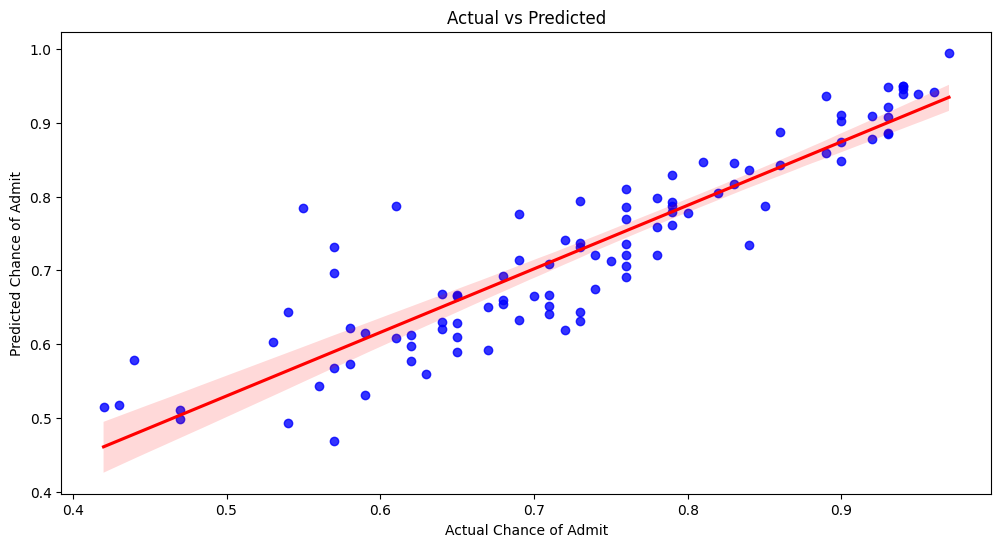

In [ ]:
plt.figure(figsize=(12,6))
sns.regplot(x=test_y,y=ridge_model.predict(test_x_scaled),scatter_kws={'color':'blue'},line_kws={'color':'red'})
plt.title('Actual vs Predicted')
plt.xlabel('Actual Chance of Admit')
plt.ylabel('Predicted Chance of Admit')
plt.show()

#Business insights

In [ ]:
#Let's give Business inights based on coeffecients and correlation

In [ ]:
df.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65


<Axes: >

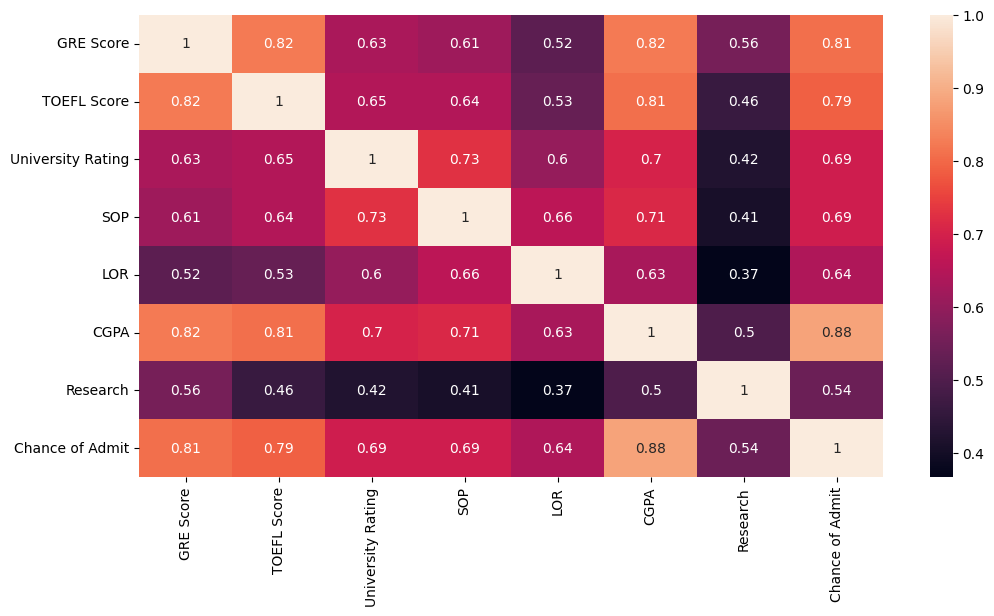

In [ ]:
plt.figure(figsize=(12,6))
sns.heatmap(df.corr(),annot=True)

In [ ]:
linear_model.coef_

array([0.0185961 , 0.0178504 , 0.00629967, 0.00360394, 0.01545244,
       0.07109061, 0.01096916])

In [ ]:
Feature_importance=pd.DataFrame({'Features':df.columns[:-1],'coeffecients':linear_model.coef_.flatten()})
Feature_importance.sort_values(by='coeffecients',ascending=False,inplace=True)

In [ ]:
Feature_importance

,Features,coeffecients
5,CGPA,0.071091
0,GRE Score,0.018596
1,TOEFL Score,0.017850
4,LOR,0.015452
6,Research,0.010969
2,University Rating,0.006300
3,SOP,0.003604


1.High Accuracy: An 81% accuracy for a linear regression model is a very good
result. This suggests that the model is capturing the underlying relationships in the data effectively.

2.Multicollinearity Management: You correctly identified that multicollinearity between highly correlated features (GRE, TOEFL, CGPA) can affect model stability. The fact that the model still achieved 81% accuracy despite this indicates it's robust. The use of Lasso and Ridge regularization models is the correct approach to handle this issue, as they are specifically designed to manage multicollinearity by penalizing large coefficients.

3.Correct Feature Importance: Your analysis of feature importance makes intuitive sense. CGPA, GRE Score, and TOEFL Score are typically the most significant predictors for university admissions.

4.Handling Less Important Features: You've also correctly identified that features with low importance, such as University Rating and SOP, can still play a role. This nuanced understanding shows that you've gone beyond a simple feature ranking and considered their practical impact.

5.Assumption Validation: The fact that all assumptions of linear regression hold true is crucial. This validates your choice of model and strengthens your confidence in the results.





Recommendations


Work Experience: Relevant professional experience that can provide insights into practical skills.

Internships: Participation in internships that reflect real-world application of knowledge and skills.

Extracurricular Activities: Involvement in clubs, sports, or volunteer work that demonstrates leadership, teamwork, and diverse interests.